In [2]:
# Importing libraries for analysis, visualization nd clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)

In [3]:
# Loading both datset and understanding the data.
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trader data shape:", trades.shape)
print("Sentiment data shape:", sentiment.shape)

Trader data shape: (211224, 16)
Sentiment data shape: (2644, 4)


In [4]:
# Checking column names
print("Trader columns:")
print(trades.columns.tolist())

print("\nSentiment columns:")
print(sentiment.columns.tolist())

Trader columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment columns:
['timestamp', 'value', 'classification', 'date']


In [5]:
# Removing extra spaces from column names
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

In [6]:
# Converting trader timestamp into datetime format
# dayfirst=True is used because Timestamp IST is like 02-12-2024
trades["trade_datetime"] = pd.to_datetime(trades["Timestamp IST"],errors="coerce",dayfirst=True)

# Extracting only date from datetime
trades["date"] = trades["trade_datetime"].dt.date

# Convert sentiment date into date format
sentiment["date"] = pd.to_datetime(sentiment["date"],errors="coerce").dt.date

# Check result
trades[["Timestamp IST", "trade_datetime", "date"]].head()

,Timestamp IST,trade_datetime,date
0,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
1,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
2,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
3,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
4,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02


In [7]:
# Merging trader data with sentiment data using date
merged = trades.merge(sentiment[["date", "value", "classification"]], on="date",how="left")

# Display first few rows
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_datetime,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed


In [8]:
# Checking how many trades do not have sentiment data
missing_sentiment = merged["classification"].isna().sum()

print("Missing sentiment rows:", missing_sentiment)

Missing sentiment rows: 6


In [9]:
# 6 rows are missing sentiment, so we will remove them
merged = merged.dropna(subset=["classification"])

print("Rows after cleaning:", merged.shape)

print("Remaining missing sentiment:",merged["classification"].isna().sum())

Rows after cleaning: (211218, 20)
Remaining missing sentiment: 0


In [10]:
# Checking both value and classification columns
# value = Fear & Greed numerical score
# classification = Fear / Greed / Extreme Fear / Extreme Greed

merged[["value", "classification"]].head()

,value,classification
0,80.0,Extreme Greed
1,80.0,Extreme Greed
2,80.0,Extreme Greed
3,80.0,Extreme Greed
4,80.0,Extreme Greed


In [11]:
# Converting important columns into numeric format
merged["closedPnL"] = pd.to_numeric(merged["Closed PnL"],errors="coerce")

merged["size_tokens"] = pd.to_numeric(merged["Size Tokens"],errors="coerce")

merged["size_usd"] = pd.to_numeric(merged["Size USD"],errors="coerce")

merged["execution_price"] = pd.to_numeric(merged["Execution Price"],errors="coerce")

merged["fear_greed_value"] = pd.to_numeric(merged["value"],errors="coerce")

In [12]:
# Creating new features 
# In this, trade value is taken from Size USD
merged["trade_value"] = merged["size_usd"]

# Winning trade means Closed PnL is greater than 0
merged["is_win"] = merged["closedPnL"] > 0

# Creating month column for monthly analysis
merged["month"] = pd.to_datetime(merged["date"]).dt.to_period("M").astype(str)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_datetime,date,value,classification,closedPnL,size_tokens,size_usd,execution_price,fear_greed_value,trade_value,is_win,month
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,0.0,986.87,7872.16,7.9769,80.0,7872.16,False,2024-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,0.0,16.00,127.68,7.9800,80.0,127.68,False,2024-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,0.0,144.09,1150.63,7.9855,80.0,1150.63,False,2024-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,0.0,142.98,1142.04,7.9874,80.0,1142.04,False,2024-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed,0.0,8.73,69.75,7.9894,80.0,69.75,False,2024-12


In [13]:
# statistical overview
merged[["closedPnL","size_tokens","size_usd", "execution_price","fear_greed_value"]].describe()

,closedPnL,size_tokens,size_usd,execution_price,fear_greed_value
count,211218.000000,2.112180e+05,2.112180e+05,211218.000000,211218.000000
mean,48.549304,4.623341e+03,5.639192e+03,11415.047529,51.649656
std,917.989791,1.042744e+05,3.657557e+04,29448.010305,21.012784
min,-117990.104100,8.740000e-07,0.000000e+00,0.000005,10.000000
25%,0.000000,2.940000e+00,1.937900e+02,4.858550,33.000000
50%,0.000000,3.200000e+01,5.970200e+02,18.280000,49.000000
75%,5.790132,1.878900e+02,2.058878e+03,101.895000,72.000000
max,135329.090100,1.582244e+07,3.921431e+06,109004.000000,94.000000


In [14]:
# Counting number of trades under each sentiment

sentiment_counts = merged["classification"].value_counts()

print(sentiment_counts)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


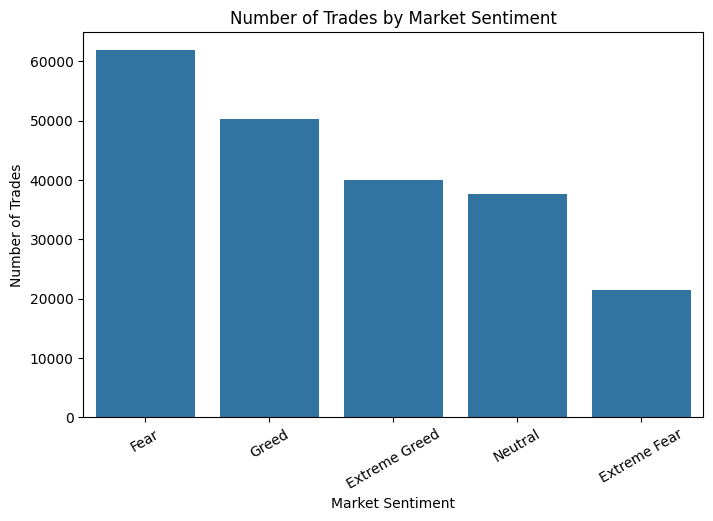

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=merged,x="classification",order=sentiment_counts.index)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=30)

plt.show()

In [16]:
# Checking which sentiment has highest profit and win rate
sentiment_summary = merged.groupby("classification").agg(
    total_trades=("closedPnL","count"),
    total_pnl=("closedPnL","sum"),
    average_pnl=("closedPnL","mean"),
    median_pnl=("closedPnL","median"),
    win_rate=("is_win","mean"),
    average_trade_value=("trade_value","mean")
).reset_index()

sentiment_summary["win_rate"] = sentiment_summary["win_rate"] * 100

sentiment_summary

,classification,total_trades,total_pnl,average_pnl,median_pnl,win_rate,average_trade_value
0,Extreme Fear,21400,7.391102e+05,34.537862,0.0,37.060748,5349.731843
1,Extreme Greed,39992,2.715171e+06,67.892861,0.0,46.494299,3112.251565
2,Fear,61837,3.357155e+06,54.290400,0.0,42.076750,7816.109931
3,Greed,50303,2.150129e+06,42.743559,0.0,38.482794,5736.884375
4,Neutral,37686,1.292921e+06,34.307718,0.0,39.699093,4782.732661


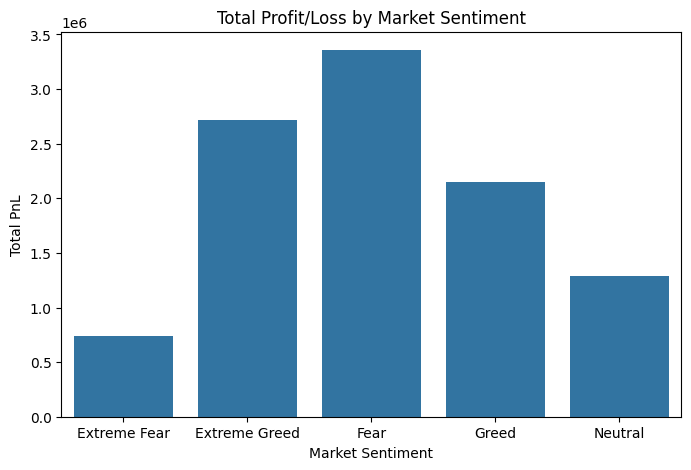

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(data=sentiment_summary,x="classification",y="total_pnl")

plt.title("Total Profit/Loss by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total PnL")

plt.show()

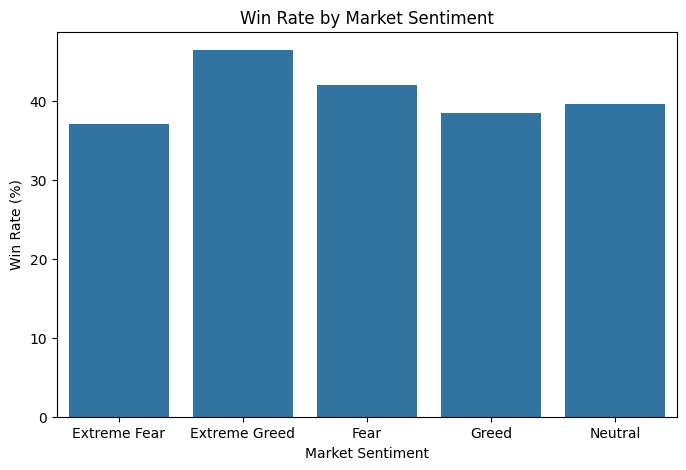

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(data=sentiment_summary,x="classification",y="win_rate")

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [19]:
# understanding Correlation Between Fear & Greed Score and PNl to check whether higher market sentiment scores lead to higher profits

correlation = merged[
    ["fear_greed_value","closedPnL"]
].corr()

correlation

,fear_greed_value,closedPnL
fear_greed_value,1.000000,0.008121
closedPnL,0.008121,1.000000


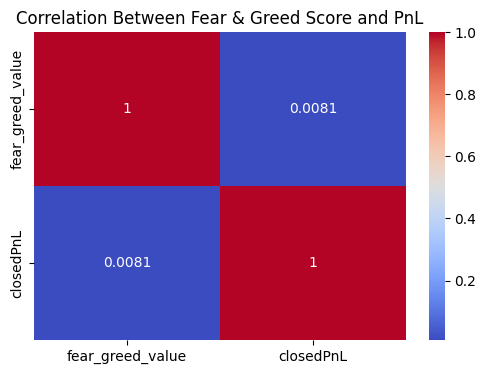

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Correlation Between Fear & Greed Score and PnL")
plt.show()

In [21]:
# Top 10 Traders During Fear
fear_data = merged[merged["classification"] == "Fear"]

top_fear_traders = fear_data.groupby("Account").agg(
    total_pnl=("closedPnL","sum"),
    total_trades=("closedPnL","count"),
    win_rate=("is_win","mean")
).reset_index()

top_fear_traders["win_rate"] *= 100

top_fear_traders = top_fear_traders.sort_values( "total_pnl",ascending=False).head(10)

top_fear_traders

,Account,total_pnl,total_trades,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.113374e+06,1778,52.643420
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,6.208724e+05,12437,49.827129
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,3.671662e+05,5981,37.050660
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,2.967817e+05,1396,40.902579
30,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2.367977e+05,1181,49.872989
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,1.512927e+05,1745,29.684814
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1.445143e+05,431,64.501160
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,9.964828e+04,98,35.714286
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9.316516e+04,3005,32.712146
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,5.597880e+04,12901,37.655996


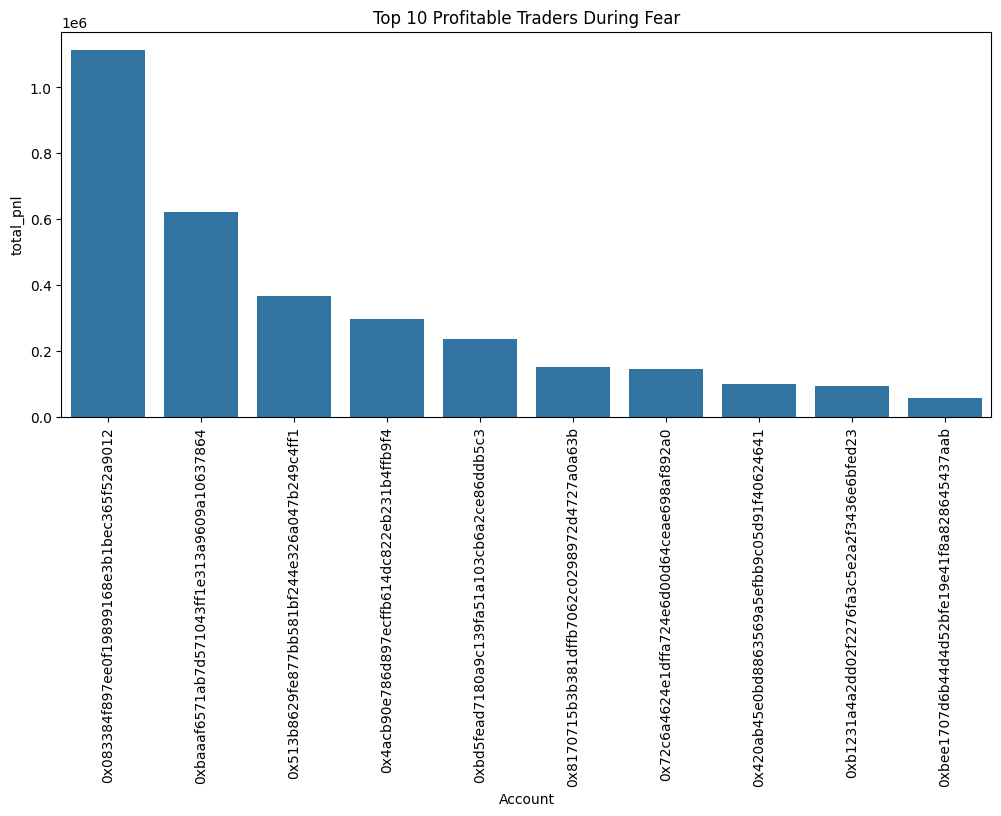

In [22]:
# visualizing bar chart for top 10 profitable trader during fear
plt.figure(figsize=(12,5))
sns.barplot(data=top_fear_traders,x="Account",y="total_pnl")
plt.title("Top 10 Profitable Traders During Fear")
plt.xticks(rotation=90)
plt.show()

In [23]:
# Top 10 Traders During Greed
greed_data = merged[merged["classification"] == "Greed"]

top_greed_traders = greed_data.groupby("Account").agg(
    total_pnl=("closedPnL","sum"),
    total_trades=("closedPnL","count"),
    win_rate=("is_win","mean")
).reset_index()

top_greed_traders["win_rate"] *= 100

top_greed_traders = top_greed_traders.sort_values("total_pnl",ascending=False).head(10)

top_greed_traders

,Account,total_pnl,total_trades,win_rate
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,534058.236330,5889,27.322126
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,453595.318176,593,31.703204
0,0x083384f897ee0f19899168e3b1bec365f52a9012,276719.270187,574,16.027875
30,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,243399.513140,7338,46.470428
9,0x430f09841d65beb3f27765503d0f850b8bce7713,227680.491734,772,63.730570
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,163047.664946,3169,37.645945
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,96392.783186,1135,59.559471
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,95937.394195,2618,80.786860
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,79023.471493,2334,34.361611
22,0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,60254.251561,1199,33.778148


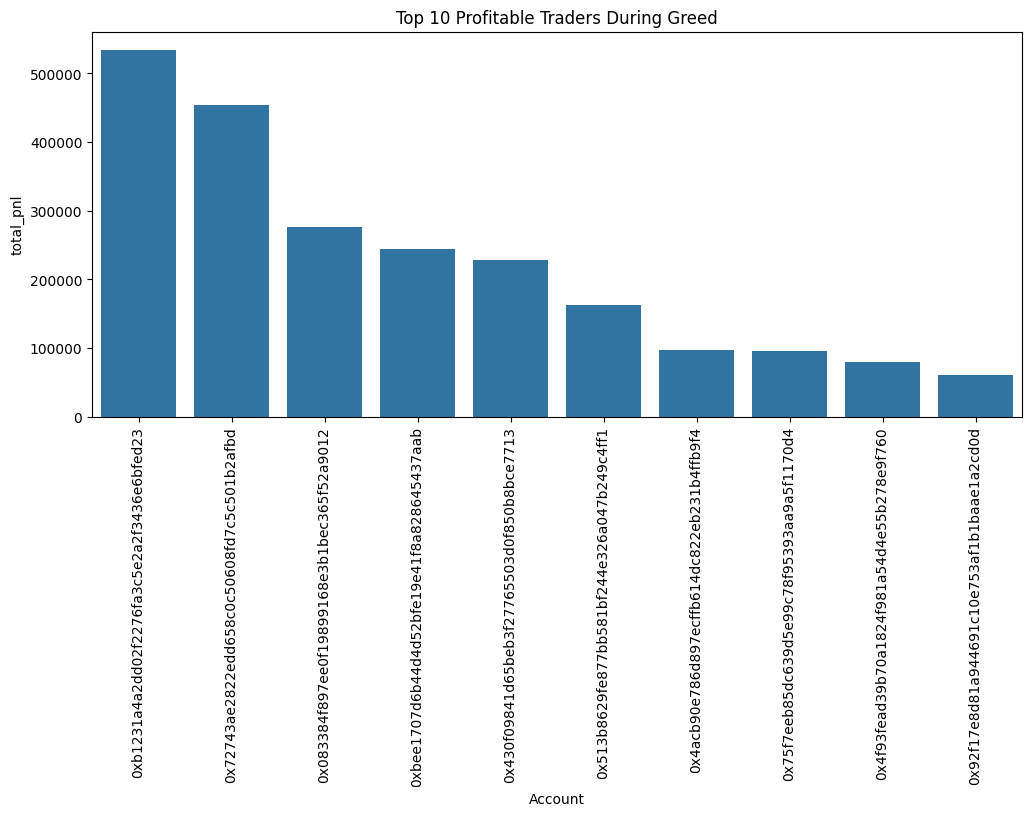

In [24]:
plt.figure(figsize=(12,5))
sns.barplot(data=top_greed_traders,x="Account",y="total_pnl")
plt.title("Top 10 Profitable Traders During Greed")
plt.xticks(rotation=90)
plt.show()

In [25]:
# Coin performance analysis
coin_summary = merged.groupby(["classification","Coin"]).agg(
    total_pnl=("closedPnL","sum"),
    average_pnl=("closedPnL","mean"),
    total_trades=("closedPnL","count"),
    win_rate=("is_win","mean")
).reset_index()

coin_summary["win_rate"] *= 100

coin_summary.sort_values("total_pnl",ascending=False).head(20)

,classification,Coin,total_pnl,average_pnl,total_trades,win_rate
88,Extreme Greed,@107,1.988619e+06,191.158211,10403,56.166490
324,Fear,HYPE,8.403064e+05,30.063552,27951,43.433151
361,Fear,SOL,7.415943e+05,189.472224,3914,50.025549
387,Greed,@107,7.243423e+05,86.251763,8398,45.891879
315,Fear,ETH,6.750646e+05,236.864764,2850,41.684211
307,Fear,BTC,4.826496e+05,48.900673,9870,38.551165
41,Extreme Fear,HYPE,4.820838e+05,46.904438,10278,39.686709
539,Greed,SOL,4.516900e+05,284.798243,1586,28.688525
472,Greed,ETH,3.510360e+05,98.219366,3574,25.937325
694,Neutral,SOL,3.033762e+05,216.697282,1400,52.142857


In [26]:
# coin vs sentiment analysis using heatmap
top_20_coins = ( merged.groupby("Coin")["closedPnL"].sum().sort_values(ascending=False).head(20).index)

heatmap_data = merged[merged["Coin"].isin(top_20_coins)].pivot_table(values="closedPnL",index="Coin",columns="classification",aggfunc="sum",
                                                                     fill_value=0)

heatmap_data

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Coin,,,,,
@107,-136085.368300,1.988619e+06,-12514.843274,724342.305860,219551.950858
AIXBT,0.000000,1.261506e+03,10367.247059,40092.549106,21990.866694
AVAX,433.644636,1.405969e+02,186.450938,12096.549815,35440.071585
BERA,12090.904233,0.000000e+00,-27.646404,83243.565498,-21617.076740
BTC,3056.840313,1.008827e+05,482649.644056,115475.191549,165980.345627
DOGE,0.000000,2.079902e+04,7907.371107,3027.303644,115809.466287
ENA,2286.628954,2.522957e+04,160316.233716,33865.081319,-4368.013180
ETH,274320.230690,-4.201607e+04,675064.576785,351036.012914,61574.088598
ETHFI,0.000000,0.000000e+00,10801.336599,30454.400091,2673.269384


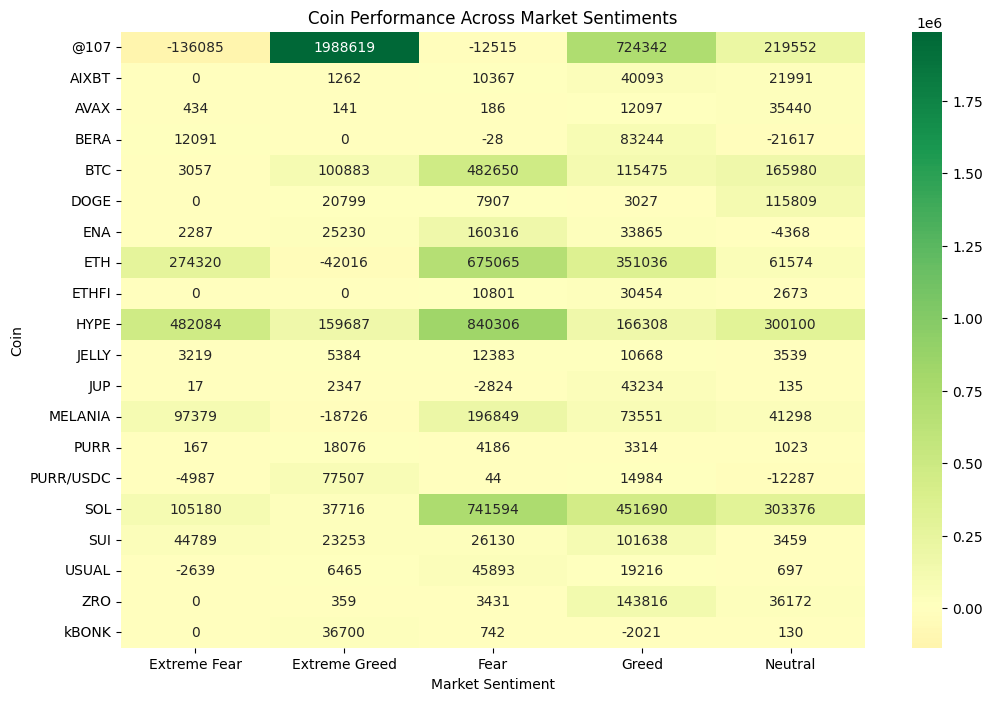

In [27]:
# Heatmap showing coin performance across different market sentiments

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,      # show values inside boxes
    fmt=".0f",       # no decimal places
    cmap="RdYlGn",   # red = lower, green = higher
    center=0
)

plt.title("Coin Performance Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Coin")

plt.show()

In [28]:
side_summary = merged.groupby(["classification","Side"]).agg(
    total_trades=("closedPnL","count"),
    total_pnl=("closedPnL","sum"),
    average_pnl=("closedPnL","mean"),
    win_rate=("is_win","mean")
).reset_index()

side_summary["win_rate"] *= 100

side_summary

,classification,Side,total_trades,total_pnl,average_pnl,win_rate
0,Extreme Fear,BUY,10935,3.730434e+05,34.114627,20.164609
1,Extreme Fear,SELL,10465,3.660668e+05,34.980106,54.715719
2,Extreme Greed,BUY,17940,1.883508e+05,10.498927,31.142698
3,Extreme Greed,SELL,22052,2.526821e+06,114.584643,58.983312
4,Fear,BUY,30270,1.935073e+06,63.927104,26.299967
5,Fear,SELL,31567,1.422082e+06,45.049641,57.205309
6,Greed,BUY,24576,6.144566e+05,25.002302,31.807454
7,Greed,SELL,25727,1.535673e+06,59.691091,44.859486
8,Neutral,BUY,18969,5.544151e+05,29.227429,24.002320
9,Neutral,SELL,18717,7.385056e+05,39.456408,55.607202


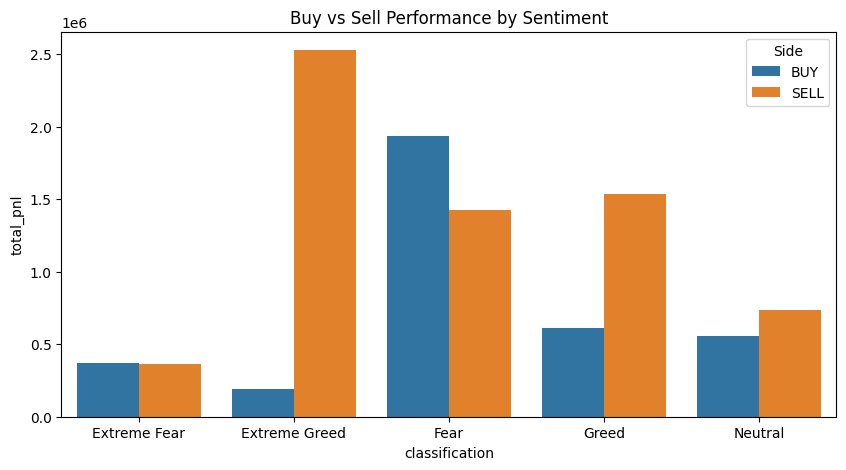

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=side_summary,
    x="classification",
    y="total_pnl",
    hue="Side"
)

plt.title("Buy vs Sell Performance by Sentiment")

plt.show()

In [30]:
# Monthly analysis shows how trader performance changes month by month

monthly_summary = merged.groupby(["month", "classification"]).agg(
    total_pnl=("closedPnL", "sum"),
    total_trades=("closedPnL", "count"),
    average_pnl=("closedPnL", "mean"),
    win_rate=("is_win", "mean")
).reset_index()

# Converting win rate into percentage
monthly_summary["win_rate"] = monthly_summary["win_rate"] * 100
monthly_summary.head()

,month,classification,total_pnl,total_trades,average_pnl,win_rate
0,2023-05,Greed,0.000000,3,0.000000,0.000000
1,2023-12,Extreme Greed,0.000000,9,0.000000,0.000000
2,2023-12,Greed,2016.006985,332,6.072310,36.746988
3,2024-01,Extreme Greed,-990.439364,91,-10.883949,25.274725
4,2024-01,Greed,-3057.257806,1806,-1.692834,25.802879


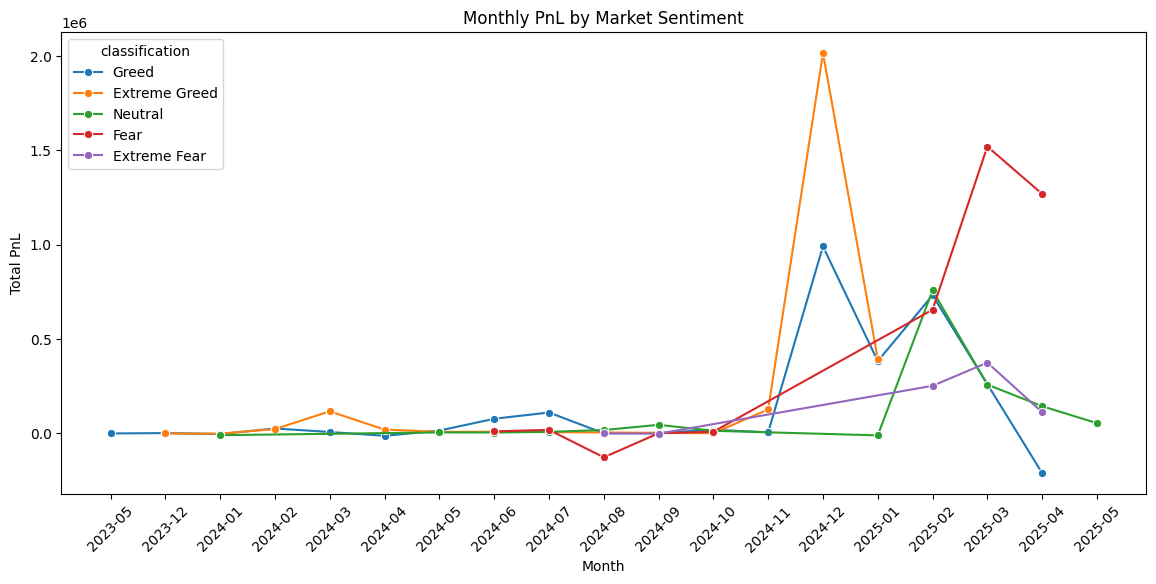

In [31]:
# Plotting monthly PnL by market sentiment

plt.figure(figsize=(14,6))

sns.lineplot(data=monthly_summary,x="month",y="total_pnl",hue="classification",marker="o")
plt.title("Monthly PnL by Market Sentiment")
plt.xlabel("Month")
plt.ylabel("Total PnL")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Showing the top 10 most profitable month and sentiment combinations

top_months = monthly_summary.sort_values("total_pnl",ascending=False).head(10)

top_months

,month,classification,total_pnl,total_trades,average_pnl,win_rate
36,2024-12,Extreme Greed,2.014363e+06,19192,104.958477,48.801584
46,2025-03,Fear,1.519373e+06,23501,64.651431,49.359602
49,2025-04,Fear,1.268536e+06,24068,52.706316,40.747050
37,2024-12,Greed,9.907080e+05,10692,92.658811,45.725776
44,2025-02,Neutral,7.573572e+05,21732,34.849861,41.786306
43,2025-02,Greed,7.317253e+05,6338,115.450512,39.823288
42,2025-02,Fear,6.555645e+05,12975,50.525202,32.971098
38,2025-01,Extreme Greed,3.946024e+05,10328,38.207045,43.590240
39,2025-01,Greed,3.832604e+05,8670,44.205352,41.787774
45,2025-03,Extreme Fear,3.751093e+05,10433,35.954115,35.646506


In [33]:
# K-Means clustering groups traders based on similar trading behavior

trader_features = merged.groupby("Account").agg(
    total_pnl=("closedPnL", "sum"),
    average_pnl=("closedPnL", "mean"),
    total_trades=("closedPnL", "count"),
    win_rate=("is_win", "mean"),
    average_trade_value=("trade_value", "mean")
).reset_index()

# Converting win rate into percentage
trader_features["win_rate"] = trader_features["win_rate"] * 100

trader_features.head()

,Account,total_pnl,average_pnl,total_trades,win_rate,average_trade_value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,35.961236,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,7280,44.271978,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,3809,30.191651,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,13311,43.858463,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,3239,51.991355,3138.894782


In [34]:
# Select only numeric columns for clustering

cluster_columns = ["total_pnl","average_pnl","total_trades","win_rate","average_trade_value"]
X = trader_features[cluster_columns]

# Replacing missing values with 0
X = X.fillna(0)

# Scaling the data because K-Means uses distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
# Creating 4 groups of traders

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

trader_features["cluster"] = kmeans.fit_predict(X_scaled)

trader_features.head()

,Account,total_pnl,average_pnl,total_trades,win_rate,average_trade_value,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,35.961236,16159.576734,1
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,7280,44.271978,1653.226327,2
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,3809,30.191651,8893.000898,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,13311,43.858463,507.626933,2
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,3239,51.991355,3138.894782,2


In [36]:
# Understanding the average behavior of each trader group

cluster_summary = trader_features.groupby("cluster").agg(
    trader_count=("Account", "count"),
    avg_total_pnl=("total_pnl", "mean"),
    avg_trades=("total_trades", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_value=("average_trade_value", "mean")
).reset_index()

cluster_summary

,cluster,trader_count,avg_total_pnl,avg_trades,avg_win_rate,avg_trade_value
0,0,3,7.184466e+05,23756.333333,56.889621,2551.820922
1,1,3,1.528012e+06,10262.333333,36.597996,18131.347464
2,2,19,6.868842e+04,5232.789474,37.824598,5193.149927
3,3,7,3.157189e+05,1391.285714,41.482525,4497.301253


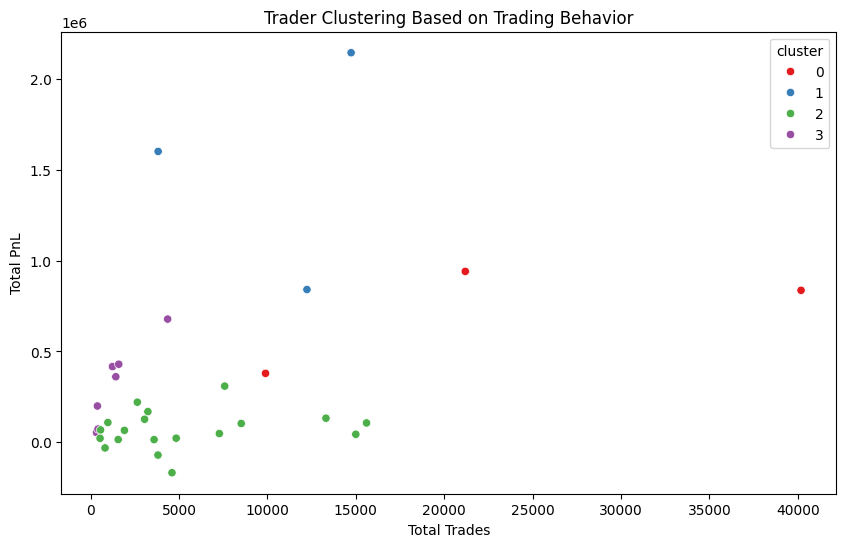

In [37]:
# Visualize trader clusters using total trades and total PnL

plt.figure(figsize=(10,6))
sns.scatterplot(data=trader_features,x="total_trades",y="total_pnl",hue="cluster",palette="Set1")
plt.title("Trader Clustering Based on Trading Behavior")
plt.xlabel("Total Trades")
plt.ylabel("Total PnL")
plt.show()

In [38]:
# Saving the processed data and summary tables

merged.to_csv("merged_trader_sentiment_data.csv", index=False)
sentiment_summary.to_csv("sentiment_summary.csv", index=False)
coin_summary.to_csv("coin_summary.csv", index=False)
side_summary.to_csv("side_summary.csv", index=False)
monthly_summary.to_csv("monthly_summary.csv", index=False)
trader_features.to_csv("trader_clusters.csv", index=False)

print("All output files saved successfully.")

All output files saved successfully.
